In [1]:
import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2

# Load data
pois = pd.read_csv('Dataset.csv')
hexagons = pd.read_csv('Grid.csv')

# Convert coordinate columns to numeric, coercing errors to NaN
pois['lon'] = pd.to_numeric(pois['lon'], errors='coerce')
pois['lat'] = pd.to_numeric(pois['lat'], errors='coerce')

hexagons['left'] = pd.to_numeric(hexagons['left'], errors='coerce')
hexagons['top'] = pd.to_numeric(hexagons['top'], errors='coerce')
hexagons['right'] = pd.to_numeric(hexagons['right'], errors='coerce')
hexagons['bottom'] = pd.to_numeric(hexagons['bottom'], errors='coerce')

# Drop rows with invalid coordinates
pois = pois.dropna(subset=['lon', 'lat'])
hexagons = hexagons.dropna(subset=['left', 'top', 'right', 'bottom'])

# Calculate hexagon centroids
hexagons['centroid_lon'] = (hexagons['left'] + hexagons['right']) / 2
hexagons['centroid_lat'] = (hexagons['top'] + hexagons['bottom']) / 2

# Assign each POI to a hexagon
def assign_hexagon(poi_lon, poi_lat, hexagons):
    mask = (
        (hexagons['left'] <= poi_lon) & (poi_lon <= hexagons['right']) &
        (hexagons['bottom'] <= poi_lat) & (poi_lat <= hexagons['top'])
    )
    match = hexagons[mask]
    return match['id'].values[0] if len(match) > 0 else None

pois['hex_id'] = pois.apply(
    lambda row: assign_hexagon(row['lon'], row['lat'], hexagons), axis=1
)
# print(hexagons)
print("First 10 POIs with assigned hexagon IDs:")
print(pois[['name', 'lon', 'lat', 'hex_id']].head(10))

print("\nTotal POIs:", len(pois))
print("POIs assigned to hexagons:", pois['hex_id'].notna().sum())
print("POIs not assigned:", pois['hex_id'].isna().sum())

First 10 POIs with assigned hexagon IDs:
                      name        lon        lat hex_id
0        مسجد ملّا اسماعیل  54.363166  31.895873   None
1         مسجد شهید ساداتی  54.383829  31.829847   None
2               مسجد حظیره  54.371269  31.897907   None
3            حسینه گازرگاه  54.373771  31.893881   None
4  مسجد دانشگاه علوم پزشکی  54.340252  31.843144   None
5               مسجد ولایت  54.366102  31.826712   None
6                      NaN  54.351083  31.839957   None
7                      NaN  54.382941  31.899845   None
8                      NaN  54.383797  31.902155   None
9            مسجد جامع یزد  54.368511  31.901437   None

Total POIs: 1112
POIs assigned to hexagons: 0
POIs not assigned: 1112


cleaning data and prepare for next step (feature engineering)

Coordinate system mismatch.

POIs: Geographic coordinates (WGS84) — longitude ~54°, latitude ~32°
Hexagons: Projected coordinates (likely UTM or Web Mercator) — values in millions
You need to transform one dataset to match the other’s coordinate system. Here’s the solution using pyproj.

In [2]:
import pandas as pd
from pyproj import Transformer

# Load data
pois = pd.read_csv('Dataset.csv')
hexagons = pd.read_csv('Grid.csv')

# Convert to numeric
pois['lon'] = pd.to_numeric(pois['lon'], errors='coerce')
pois['lat'] = pd.to_numeric(pois['lat'], errors='coerce')
hexagons['left'] = pd.to_numeric(hexagons['left'], errors='coerce')
hexagons['top'] = pd.to_numeric(hexagons['top'], errors='coerce')
hexagons['right'] = pd.to_numeric(hexagons['right'], errors='coerce')
hexagons['bottom'] = pd.to_numeric(hexagons['bottom'], errors='coerce')

# Drop NaN
pois = pois.dropna(subset=['lon', 'lat'])
hexagons = hexagons.dropna(subset=['left', 'top', 'right', 'bottom'])

# Transform POI coordinates from WGS84 to Web Mercator (EPSG:3857)
# If your hexagons use a different projection (e.g., UTM Zone 40N for Iran), 
# replace 3857 with the appropriate EPSG code
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
pois['x'], pois['y'] = transformer.transform(pois['lon'].values, pois['lat'].values)

# Calculate hexagon centroids
hexagons['center_x'] = (hexagons['left'] + hexagons['right']) / 2
hexagons['center_y'] = (hexagons['top'] + hexagons['bottom']) / 2

# Assign hexagons
def assign_hexagon(row):
    x, y = row['x'], row['y']
    mask = (
        (x >= hexagons['left']) & 
        (x <= hexagons['right']) & 
        (y >= hexagons['bottom']) & 
        (y <= hexagons['top'])
    )
    candidates = hexagons[mask]
    
    if len(candidates) == 0:
        return None
    
    distances = ((candidates['center_x'] - x)**2 + (candidates['center_y'] - y)**2)**0.5
    return candidates.loc[distances.idxmin(), 'id']

pois['hex_id'] = pois.apply(assign_hexagon, axis=1)

# Results
print("First 10 POIs with assigned hexagons:")
print(pois[['name', 'lon', 'lat', 'x', 'y', 'hex_id']].head(10))
print(f"\nTotal POIs: {len(pois)}")
print(f"Assigned: {pois['hex_id'].notna().sum()}")
print(f"Unassigned: {pois['hex_id'].isna().sum()}")

pois.to_csv('POIs_with_hexagons.csv', index=False)
print("\nSaved to POIs_with_hexagons.csv")


First 10 POIs with assigned hexagons:
                      name        lon        lat             x             y  \
0        مسجد ملّا اسماعیل  54.363166  31.895873  6.051680e+06  3.749650e+06   
1         مسجد شهید ساداتی  54.383829  31.829847  6.053980e+06  3.740996e+06   
2               مسجد حظیره  54.371269  31.897907  6.052582e+06  3.749917e+06   
3            حسینه گازرگاه  54.373771  31.893881  6.052861e+06  3.749389e+06   
4  مسجد دانشگاه علوم پزشکی  54.340252  31.843144  6.049129e+06  3.742738e+06   
5               مسجد ولایت  54.366102  31.826712  6.052007e+06  3.740585e+06   
6                      NaN  54.351083  31.839957  6.050335e+06  3.742321e+06   
7                      NaN  54.382941  31.899845  6.053881e+06  3.750171e+06   
8                      NaN  54.383797  31.902155  6.053977e+06  3.750474e+06   
9            مسجد جامع یزد  54.368511  31.901437  6.052275e+06  3.750380e+06   

    hex_id  
0  17205.0  
1  19432.0  
2  17983.0  
3  18297.0  
4  15055.0  
5  

Investigating the 7 unassigned POIs

In [3]:
print(pois[pois['hex_id'].isna()][['name', 'lon', 'lat']])

                        name        lon        lat
69   مجموعه ورزشی شهید نصیری  54.328391  31.858753
152                      NaN  54.313098  31.833249
230             ورزشگاه معلم  54.382191  31.920325
233   میدان میوه تره بار یزد  54.366374  31.792575
247                      NaN  54.328791  31.858544
356                      NaN  54.328777  31.858555
382            خانه ملک زاده  54.369065  31.904537


For each hexagon centroid, calculate distance to the nearest POI of each important type

In [6]:
# ============================================================
# CELL 3: Distance from each hexagon centroid to the nearest
#         POI of every fclass (POI type)
# ============================================================
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree          # efficient nearest-neighbour search

# ============================================================
# 1. Load the data you already prepared
# ============================================================
pois     = pd.read_csv('POIs_with_hexagons.csv')   # x, y, fclass
hexagons = pd.read_csv('Grid.csv')

# Make sure hexagon bounds are numeric and valid
for col in ['left', 'top', 'right', 'bottom']:
    hexagons[col] = pd.to_numeric(hexagons[col], errors='coerce')
hexagons = hexagons.dropna(subset=['left', 'top', 'right', 'bottom'])

# Hexagon centroids (in the SAME projected CRS – Web Mercator, EPSG:3857)
hexagons['center_x'] = (hexagons['left']   + hexagons['right'])  / 2
hexagons['center_y'] = (hexagons['top']    + hexagons['bottom']) / 2

# ============================================================
# 2. Discover all POI types (fclass) in the data
# ============================================================
unique_fclasses = pois['fclass'].dropna().unique()
print(f"Found {len(unique_fclasses)} POI types:")
for fc in unique_fclasses:
    cnt = (pois['fclass'] == fc).sum()
    print(f"   {fc}: {cnt} POIs")

# ============================================================
# 3. Build one cKDTree for each POI type
# ============================================================
trees = {}
for fc in unique_fclasses:
    subset = pois[pois['fclass'] == fc][['x', 'y']].dropna().values
    if len(subset) == 0:
        trees[fc] = None
        print(f"WARNING: No valid coordinates for '{fc}' – will return NaN")
    else:
        trees[fc] = cKDTree(subset)

# ============================================================
# 4. Query each hexagon centroid against every tree
# ============================================================
centroids = hexagons[['center_x', 'center_y']].values

# We'll store the distances in the hexagons DataFrame
for fc in unique_fclasses:
    tree = trees[fc]
    if tree is None:
        hexagons[f'dist_{fc}'] = np.nan
        continue

    # Query returns (distances, indices).  k=1  → nearest neighbour.
    dist, idx = tree.query(centroids, k=1)
    hexagons[f'dist_{fc}'] = dist          # distance in meters (Web Mercator)

# ============================================================
# 5. (Optional) Add a column for the absolute nearest POI type & distance
# ============================================================
dist_cols = [f'dist_{fc}' for fc in unique_fclasses]
hexagons['min_dist_overall'] = hexagons[dist_cols].min(axis=1)
hexagons['nearest_type']     = hexagons[dist_cols].idxmin(axis=1).str.replace('dist_', '')

# ============================================================
# 6. Preview and save
# ============================================================
print("\n--- Sample of the result ---")
display_cols = ['id', 'center_x', 'center_y', 'min_dist_overall', 'nearest_type'] + dist_cols
print(hexagons[display_cols].head(10))

hexagons.to_csv('Hexagons_with_nearest_POI_distances.csv', index=False)
print("\n✅ Saved to Hexagons_with_nearest_POI_distances.csv")


Found 82 POI types:
   muslim: 24 POIs
   muslim_shia: 30 POIs
   jewish: 10 POIs
   theme_park: 2 POIs
   graveyard: 19 POIs
   sports_centre: 12 POIs
   park: 135 POIs
   attraction: 45 POIs
   university: 27 POIs
   school: 64 POIs
   mall: 8 POIs
   hospital: 15 POIs
   bank: 54 POIs
   department_store: 4 POIs
   clinic: 22 POIs
   hotel: 68 POIs
   pitch: 9 POIs
   restaurant: 63 POIs
   swimming_pool: 5 POIs
   guesthouse: 13 POIs
   college: 9 POIs
   library: 7 POIs
   cinema: 4 POIs
   shelter: 1 POIs
   convenience: 8 POIs
   fire_station: 4 POIs
   stadium: 2 POIs
   car_dealership: 12 POIs
   monument: 2 POIs
   market_place: 5 POIs
   police: 11 POIs
   museum: 8 POIs
   prison: 2 POIs
   courthouse: 2 POIs
   town_hall: 3 POIs
   castle: 2 POIs
   cafe: 39 POIs
   supermarket: 41 POIs
   fast_food: 35 POIs
   hairdresser: 11 POIs
   optician: 10 POIs
   jeweller: 11 POIs
   pharmacy: 20 POIs
   bookshop: 3 POIs
   computer_shop: 8 POIs
   mobile_phone_shop: 13 POIs
   at

In [7]:
# ============================================================
# CELL 4: Count POIs within a fixed radius (e.g., 500m)
#         from each hexagon centroid, per fclass
# ============================================================
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# ============================================================
# 1. Load data
# ============================================================
pois     = pd.read_csv('POIs_with_hexagons.csv')   # x, y, fclass
hexagons = pd.read_csv('Grid.csv')

# Ensure hexagon bounds are numeric
for col in ['left', 'top', 'right', 'bottom']:
    hexagons[col] = pd.to_numeric(hexagons[col], errors='coerce')
hexagons = hexagons.dropna(subset=['left', 'top', 'right', 'bottom'])

# Hexagon centroids (same projection as POIs — Web Mercator, EPSG:3857)
hexagons['center_x'] = (hexagons['left']   + hexagons['right'])  / 2
hexagons['center_y'] = (hexagons['top']    + hexagons['bottom']) / 2

# ============================================================
# 2. Set your radius (in meters — Web Mercator units)
# ============================================================
RADIUS = 500   # ← change this to any value you need

# ============================================================
# 3. Discover all POI types
# ============================================================
unique_fclasses = pois['fclass'].dropna().unique()
print(f"Counting POIs within {RADIUS}m for {len(unique_fclasses)} types:")
for fc in unique_fclasses:
    print(f"   {fc}: {(pois['fclass'] == fc).sum()} total POIs")

# ============================================================
# 4. Build one cKDTree per POI type
# ============================================================
trees = {}
for fc in unique_fclasses:
    subset = pois[pois['fclass'] == fc][['x', 'y']].dropna().values
    if len(subset) == 0:
        trees[fc] = None
    else:
        trees[fc] = cKDTree(subset)

# ============================================================
# 5. Count POIs within radius for each hexagon centroid
# ============================================================
centroids = hexagons[['center_x', 'center_y']].values

for fc in unique_fclasses:
    tree = trees[fc]
    if tree is None:
        hexagons[f'count_{fc}'] = 0
        continue

    # query_ball_point returns indices of all POIs within RADIUS
    idx_list = tree.query_ball_point(centroids, r=RADIUS)

    # Count how many POIs in each hexagon's list
    hexagons[f'count_{fc}'] = [len(lst) for lst in idx_list]

# ============================================================
# 6. Add a total count across all types
# ============================================================
count_cols = [f'count_{fc}' for fc in unique_fclasses]
hexagons['count_total'] = hexagons[count_cols].sum(axis=1)

# ============================================================
# 7. Preview and save
# ============================================================
display_cols = ['id', 'center_x', 'center_y', 'count_total'] + count_cols
print(f"\n--- Hexagons with POI counts within {RADIUS}m ---")
print(hexagons[display_cols].head(10))

# Quick summary
print(f"\nHexagons with at least one POI within {RADIUS}m: "
      f"{(hexagons['count_total'] > 0).sum()} / {len(hexagons)}")

hexagons.to_csv('Hexagons_with_POI_counts.csv', index=False)
print("\n✅ Saved to Hexagons_with_POI_counts.csv")


Counting POIs within 500m for 82 types:
   muslim: 24 total POIs
   muslim_shia: 30 total POIs
   jewish: 10 total POIs
   theme_park: 2 total POIs
   graveyard: 19 total POIs
   sports_centre: 12 total POIs
   park: 135 total POIs
   attraction: 45 total POIs
   university: 27 total POIs
   school: 64 total POIs
   mall: 8 total POIs
   hospital: 15 total POIs
   bank: 54 total POIs
   department_store: 4 total POIs
   clinic: 22 total POIs
   hotel: 68 total POIs
   pitch: 9 total POIs
   restaurant: 63 total POIs
   swimming_pool: 5 total POIs
   guesthouse: 13 total POIs
   college: 9 total POIs
   library: 7 total POIs
   cinema: 4 total POIs
   shelter: 1 total POIs
   convenience: 8 total POIs
   fire_station: 4 total POIs
   stadium: 2 total POIs
   car_dealership: 12 total POIs
   monument: 2 total POIs
   market_place: 5 total POIs
   police: 11 total POIs
   museum: 8 total POIs
   prison: 2 total POIs
   courthouse: 2 total POIs
   town_hall: 3 total POIs
   castle: 2 total

In [1]:
# ============================================================
# CELL 5: Merge distance and count features into one
#         hexagon‑level feature table
# ============================================================
import pandas as pd

# 1. Load the two files you already saved
dist_df  = pd.read_csv('Hexagons_with_nearest_POI_distances.csv')
count_df = pd.read_csv('Hexagons_with_POI_counts.csv')

print(f"Distances shape:  {dist_df.shape}")
print(f"Counts shape:     {count_df.shape}")

# 2. Identify columns that are duplicated in both (we don't want them twice)
#    Typically: id, left, top, right, bottom, center_x, center_y
common_cols = set(dist_df.columns) & set(count_df.columns)

# 3. Merge on 'id' (or a list of shared key columns), but drop duplicates from the right side
#    We'll keep all columns from dist_df and add only new ones from count_df.
new_cols_from_count = [c for c in count_df.columns if c not in common_cols or c == 'id']

merged = dist_df.merge(
    count_df[new_cols_from_count],
    on='id',
    how='outer',
    validate='1:1'          # one row per hexagon in both tables
)

# 4. (Optional but recommended) Reorder columns for readability
#    Move all 'dist_*' and 'count_*' columns together
id_info_cols = ['id', 'left', 'top', 'right', 'bottom', 'center_x', 'center_y']
meta_cols    = [c for c in merged.columns if c in ['min_dist_overall', 'nearest_type', 'count_total']]
dist_cols    = [c for c in merged.columns if c.startswith('dist_')]
count_cols   = [c for c in merged.columns if c.startswith('count_')]
other_cols   = [c for c in merged.columns if c not in id_info_cols + meta_cols + dist_cols + count_cols]

merged = merged[id_info_cols + meta_cols + dist_cols + count_cols + other_cols]

# 5. Preview
print("\n--- Merged table (first 5 rows) ---")
print(merged.head())

print(f"\nMerged shape: {merged.shape}")
print("Columns:", merged.columns.tolist())

# 6. Save
merged.to_csv('Hexagons_feature_matrix.csv', index=False)
print("\n✅ Saved to Hexagons_feature_matrix.csv")


Distances shape:  (4660, 91)
Counts shape:     (4660, 90)

--- Merged table (first 5 rows) ---
      id          left           top         right        bottom  \
0  11939  6.045619e+06  3.742083e+06  6.045850e+06  3.741883e+06   
1  12094  6.045792e+06  3.742183e+06  6.046023e+06  3.741983e+06   
2  12095  6.045792e+06  3.741983e+06  6.046023e+06  3.741783e+06   
3  12249  6.045965e+06  3.742483e+06  6.046196e+06  3.742283e+06   
4  12250  6.045965e+06  3.742283e+06  6.046196e+06  3.742083e+06   

       center_x      center_y  min_dist_overall nearest_type  count_total  \
0  6.045734e+06  3.741983e+06        548.122542         park            0   
1  6.045908e+06  3.742083e+06        565.022539         park            0   
2  6.045908e+06  3.741883e+06        375.310372         park            3   
3  6.046081e+06  3.742383e+06        846.436774         park            0   
4  6.046081e+06  3.742183e+06        646.577620         park            0   

   ...  count_food_court  count_d

In [2]:
# ============================================================
# CELL 6: Normalize distance & count features for clustering / ML
# ============================================================
import pandas as pd
import numpy as np

# --- 1. Load the merged table (from Cell 5) ---
df = pd.read_csv('Hexagons_feature_matrix.csv')

# --- 2. Identify column groups ---
id_cols   = ['id', 'left', 'top', 'right', 'bottom', 'center_x', 'center_y']
meta_cols = ['min_dist_overall', 'nearest_type', 'count_total']
dist_cols = [c for c in df.columns if c.startswith('dist_')]
count_cols = [c for c in df.columns if c.startswith('count_')]

print(f"Found {len(dist_cols)} distance columns and {len(count_cols)} count columns.")

# ============================================================
# PART A: Normalize DISTANCE columns
#         → Negative exponential decay
#         → score = exp( -distance / BANDWIDTH )
#         → Close POI → 1.0,  Far POI → 0.0
# ============================================================
BANDWIDTH = 500   # meters — same radius you used for counts

df_score = pd.DataFrame(index=df.index)
for col in dist_cols:
    fclass = col.replace('dist_', '')             # e.g. "cafe"
    df_score[f'score_{fclass}'] = np.exp(-df[col] / BANDWIDTH)

print("\nDistance scores (should all be in [0,1]):")
print(df_score.describe().round(3).iloc[[0,1,2,3,7], :5])   # min, 25%, 50%, 75%, max

# ============================================================
# PART B: Normalize COUNT columns
#         → log(1 + x) to handle zeros & skew
#         → then Z-score (mean=0, std=1)
# ============================================================
df_count_norm = pd.DataFrame(index=df.index)

for col in count_cols:
    fclass = col.replace('count_', '')
    # log1p reduces right-skew and handles zeros gracefully
    logged = np.log1p(df[col])
    # Z-score
    mu = logged.mean()
    sigma = logged.std()
    # guard against constant columns (std=0)
    if sigma == 0:
        df_count_norm[f'zcount_{fclass}'] = 0
    else:
        df_count_norm[f'zcount_{fclass}'] = (logged - mu) / sigma

print("\nCount z-scores (mean≈0, std≈1):")
print(df_count_norm.describe().round(3).iloc[[0,1,2,3,7], :5])

# ============================================================
# PART C: Also normalize meta columns
# ============================================================
# min_dist_overall → same exponential decay
df['score_min_dist_overall'] = np.exp(-df['min_dist_overall'] / BANDWIDTH)

# count_total → log1p + z-score
ct_log = np.log1p(df['count_total'])
df['zcount_total'] = (ct_log - ct_log.mean()) / ct_log.std()

# ============================================================
# PART D: Assemble final normalized table
# ============================================================
# Drop raw distance & count columns; keep normalized versions + IDs
df_norm = pd.concat([
    df[id_cols],                    # geometry & identifier
    df[['score_min_dist_overall', 'zcount_total', 'nearest_type']],
    df_score,                       # score_muslim, score_cafe, …
    df_count_norm                   # zcount_muslim, zcount_cafe, …
], axis=1)

# ============================================================
# PART E: Sanity checks
# ============================================================
print(f"\nFinal shape: {df_norm.shape}")
print(f"Any NaN? {df_norm.isna().any().any()}")
print(f"\nFirst 3 rows (first 8 columns):")
print(df_norm.iloc[:3, :8])

# ============================================================
# PART F: Save
# ============================================================
df_norm.to_csv('Hexagons_normalized.csv', index=False)
print("\n✅ Saved to Hexagons_normalized.csv")


Found 82 distance columns and 84 count columns.

Distance scores (should all be in [0,1]):
       score_muslim  score_muslim_shia  score_jewish  score_theme_park  \
count      4660.000           4660.000      4660.000          4660.000   
mean          0.099              0.137         0.018             0.019   
std           0.157              0.182         0.073             0.067   
min           0.000              0.000         0.000             0.000   
max           0.980              0.978         0.934             0.925   

       score_graveyard  
count         4660.000  
mean             0.031  
std              0.100  
min              0.000  
max              0.973  

Count z-scores (mean≈0, std≈1):
       zcount_total  zcount_muslim  zcount_muslim_shia  zcount_jewish  \
count      4660.000       4660.000            4660.000       4660.000   
mean          0.000          0.000              -0.000          0.000   
std           1.000          1.000               1.000        

C:\Users\hp\AppData\Local\Temp\ipykernel_12888\3447699681.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['score_min_dist_overall'] = np.exp(-df['min_dist_overall'] / BANDWIDTH)
C:\Users\hp\AppData\Local\Temp\ipykernel_12888\3447699681.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['zcount_total'] = (ct_log - ct_log.mean()) / ct_log.std()



✅ Saved to Hexagons_normalized.csv


Feature columns: 168
  - score_* : 83
  - zcount_*: 85
No NaN values in feature matrix ✓
Feature matrix shape: (4660, 168)
k= 2  |  Inertia=  682279.9  |  Silhouette=0.4647
k= 3  |  Inertia=  633609.3  |  Silhouette=0.4505
k= 4  |  Inertia=  603668.5  |  Silhouette=0.3034
k= 5  |  Inertia=  580248.8  |  Silhouette=0.3491
k= 6  |  Inertia=  560195.4  |  Silhouette=0.3319
k= 7  |  Inertia=  539972.3  |  Silhouette=0.3144
k= 8  |  Inertia=  527569.9  |  Silhouette=0.3134
k= 9  |  Inertia=  510967.2  |  Silhouette=0.3166
k=10  |  Inertia=  500383.2  |  Silhouette=0.3223
k=11  |  Inertia=  489167.6  |  Silhouette=0.3059
k=12  |  Inertia=  475481.4  |  Silhouette=0.3011
k=13  |  Inertia=  463159.5  |  Silhouette=0.3076
k=14  |  Inertia=  451864.0  |  Silhouette=0.3042
k=15  |  Inertia=  442665.1  |  Silhouette=0.3046


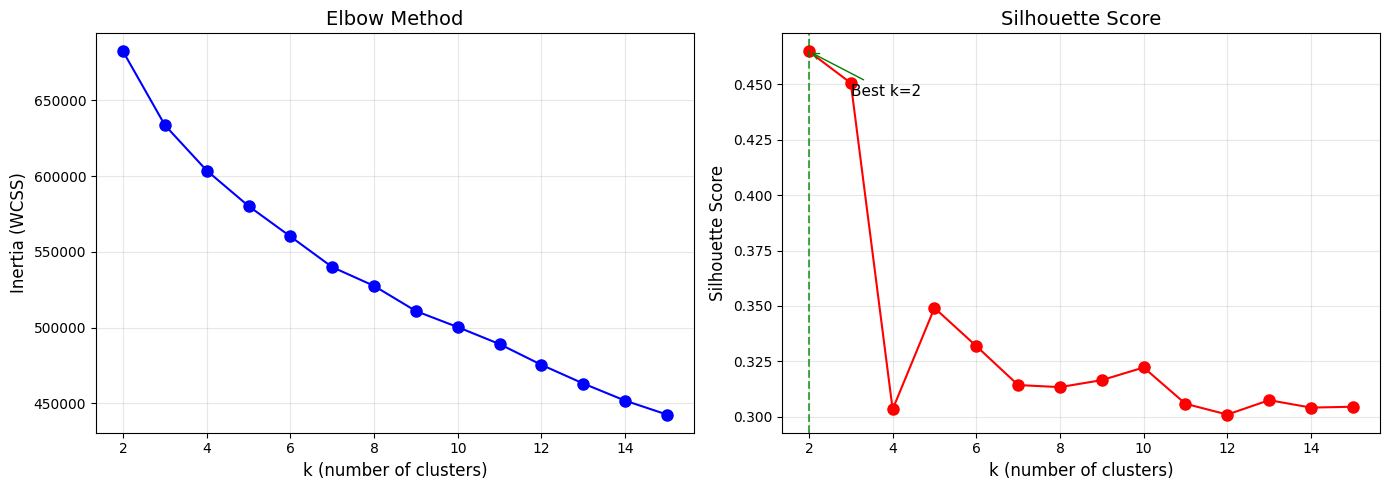


→ Clustering with k = 2

--- Cluster sizes ---
  Cluster 0:  3788 hexagons  (81.3%)
  Cluster 1:   872 hexagons  (18.7%)


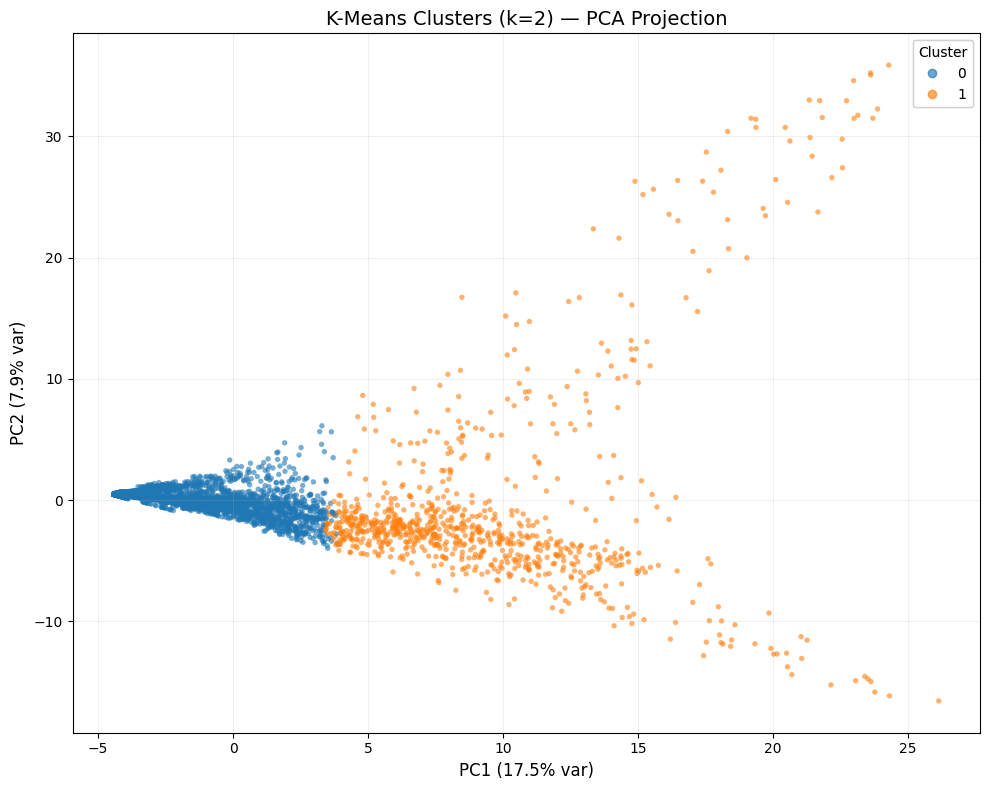

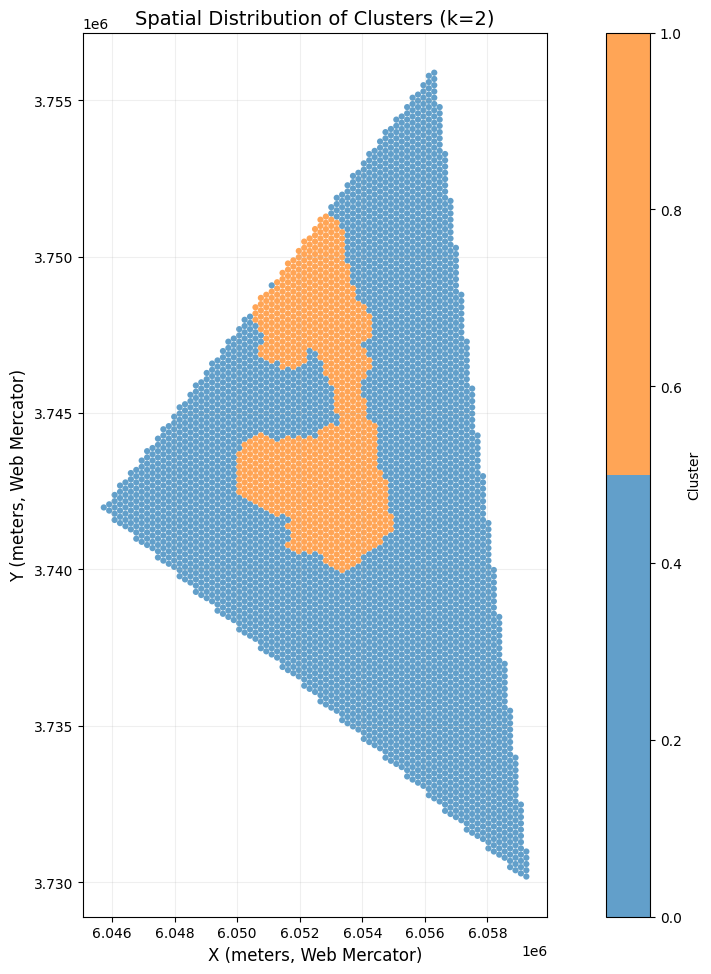


--- Top 10 most differentiating DISTANCE scores across clusters ---
cluster                     0      1
score_min_dist_overall  0.367  0.781
score_restaurant        0.105  0.456
score_bank              0.062  0.386
score_cafe              0.052  0.360
score_school            0.116  0.424
score_clothes           0.035  0.325
score_doctors           0.036  0.320
score_fast_food         0.052  0.326
score_hospital          0.043  0.292
score_clinic            0.056  0.304

--- Top 10 most differentiating COUNT z-scores across clusters ---
cluster                0      1
zcount_total      -0.349  1.516
zcount_total.2    -0.349  1.516
zcount_total.1    -0.349  1.516
zcount_restaurant -0.287  1.247
zcount_bank       -0.253  1.101
zcount_cafe       -0.251  1.089
zcount_fast_food  -0.234  1.016
zcount_clothes    -0.234  1.014
zcount_doctors    -0.231  1.003
zcount_clinic     -0.221  0.960


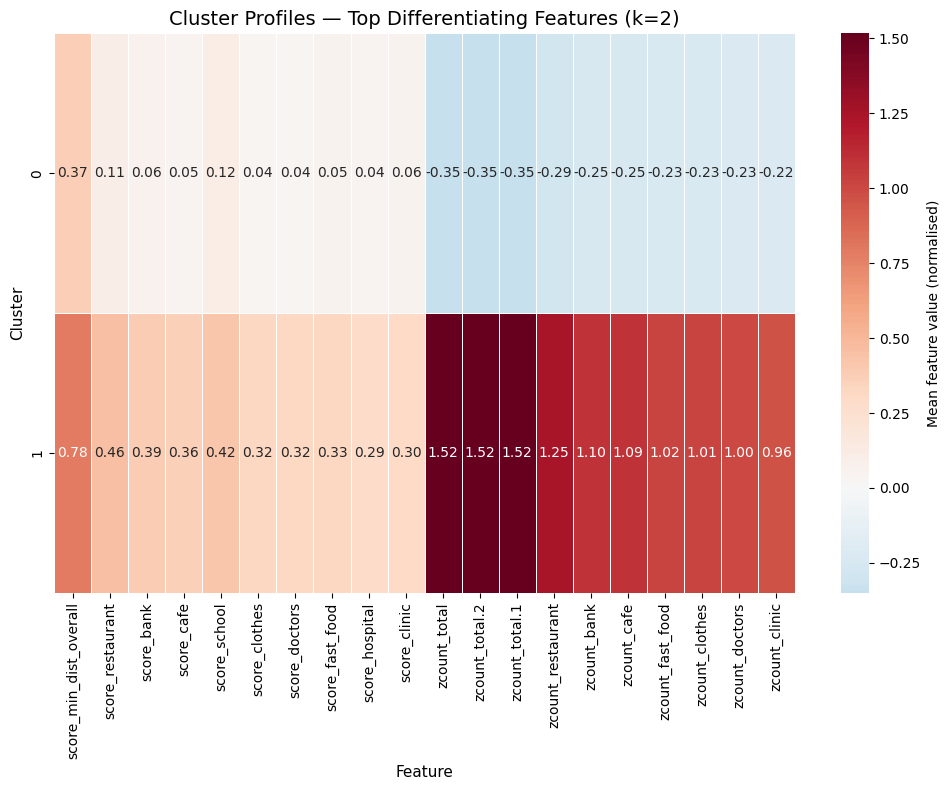


✅ Saved to Hexagons_clustered.csv
   Columns: ['id', 'left', 'top', 'right', 'bottom', 'center_x', 'center_y', 'score_min_dist_overall', 'zcount_total', 'nearest_type', 'score_muslim', 'score_muslim_shia', 'score_jewish', 'score_theme_park', 'score_graveyard', 'score_sports_centre', 'score_park', 'score_attraction', 'score_university', 'score_school', 'score_mall', 'score_hospital', 'score_bank', 'score_department_store', 'score_clinic', 'score_hotel', 'score_pitch', 'score_restaurant', 'score_swimming_pool', 'score_guesthouse', 'score_college', 'score_library', 'score_cinema', 'score_shelter', 'score_convenience', 'score_fire_station', 'score_stadium', 'score_car_dealership', 'score_monument', 'score_market_place', 'score_police', 'score_museum', 'score_prison', 'score_courthouse', 'score_town_hall', 'score_castle', 'score_cafe', 'score_supermarket', 'score_fast_food', 'score_hairdresser', 'score_optician', 'score_jeweller', 'score_pharmacy', 'score_bookshop', 'score_computer_shop', 

In [4]:
# ============================================================
# CELL 7: K-Means Clustering of Hexagons by POI Accessibility
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from matplotlib.colors import ListedColormap

# ============================================================
# 1. Load normalized data
# ============================================================
df = pd.read_csv('Hexagons_normalized.csv')

# Separate identifier / geometry columns from features
id_cols   = ['id', 'left', 'top', 'right', 'bottom', 'center_x', 'center_y', 'nearest_type']
score_cols = [c for c in df.columns if c.startswith('score_')]
zcount_cols = [c for c in df.columns if c.startswith('zcount_')]
feature_cols = score_cols + zcount_cols

print(f"Feature columns: {len(feature_cols)}")
print(f"  - score_* : {len(score_cols)}")
print(f"  - zcount_*: {len(zcount_cols)}")

# Extract feature matrix
X = df[feature_cols].values

# --- Handle any remaining NaN (shouldn't be any after Cell 6) ---
nan_mask = np.isnan(X).any(axis=1)
if nan_mask.any():
    print(f"WARNING: {nan_mask.sum()} rows have NaN features – dropping them.")
    X = X[~nan_mask]
    df_clean = df[~nan_mask].reset_index(drop=True)
else:
    df_clean = df.copy()
    print("No NaN values in feature matrix ✓")

# ============================================================
# 2. Standardize (redundant but safe — zcount already scaled,
#    score_* in [0,1]; this brings everything to same variance)
# ============================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Feature matrix shape: {X_scaled.shape}")

# ============================================================
# 3. Determine optimal k — Elbow Method + Silhouette Score
# ============================================================
K_range = range(2, 16)   # try k = 2 .. 15
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_scaled)
    inrt = km.inertia_
    inertias.append(inrt)
    sil = silhouette_score(X_scaled, labels)
    silhouettes.append(sil)
    print(f"k={k:2d}  |  Inertia={inrt:10.1f}  |  Silhouette={sil:.4f}")

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
ax1.plot(list(K_range), inertias, 'bo-', markersize=8)
ax1.set_xlabel('k (number of clusters)', fontsize=12)
ax1.set_ylabel('Inertia (WCSS)', fontsize=12)
ax1.set_title('Elbow Method', fontsize=14)
ax1.grid(True, alpha=0.3)

# Silhouette
ax2.plot(list(K_range), silhouettes, 'ro-', markersize=8)
ax2.set_xlabel('k (number of clusters)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score', fontsize=14)
ax2.grid(True, alpha=0.3)
# Mark best k
best_k_sil = list(K_range)[np.argmax(silhouettes)]
ax2.axvline(x=best_k_sil, color='green', linestyle='--', alpha=0.7)
ax2.annotate(f'Best k={best_k_sil}', xy=(best_k_sil, max(silhouettes)),
             xytext=(best_k_sil+1, max(silhouettes)-0.02),
             arrowprops=dict(arrowstyle='->', color='green'), fontsize=11)

plt.tight_layout()
plt.savefig('kmeans_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 4. CHOOSE your k (edit based on plots above)
# ============================================================
# Default: use the k that maximises silhouette score
K_CHOSEN = int(input(f"Enter chosen k (default best silhouette = {best_k_sil}): ") or best_k_sil)
print(f"\n→ Clustering with k = {K_CHOSEN}")

kmeans = KMeans(n_clusters=K_CHOSEN, random_state=42, n_init=10, max_iter=300)
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

# ============================================================
# 5. Cluster sizes
# ============================================================
cluster_counts = df_clean['cluster'].value_counts().sort_index()
print("\n--- Cluster sizes ---")
for clus, cnt in cluster_counts.items():
    print(f"  Cluster {clus}: {cnt:5d} hexagons  ({100*cnt/len(df_clean):.1f}%)")

# ============================================================
# 6. PCA — 2D visualisation of clusters
# ============================================================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_clean['pca1'] = X_pca[:, 0]
df_clean['pca2'] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(10, 8))
cmap = sns.color_palette('tab10', n_colors=K_CHOSEN)
scatter = ax.scatter(df_clean['pca1'], df_clean['pca2'],
                     c=df_clean['cluster'], cmap=ListedColormap(cmap),
                     s=15, alpha=0.6, edgecolors='none')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)', fontsize=12)
ax.set_title(f'K-Means Clusters (k={K_CHOSEN}) — PCA Projection', fontsize=14)
legend1 = ax.legend(*scatter.legend_elements(), title='Cluster', loc='best')
ax.add_artist(legend1)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('kmeans_pca.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 7. Spatial map of clusters (scatter by centroid)
# ============================================================
fig, ax = plt.subplots(figsize=(12, 10))
sc = ax.scatter(df_clean['center_x'], df_clean['center_y'],
                c=df_clean['cluster'], cmap=ListedColormap(cmap),
                s=20, alpha=0.7, edgecolors='none')
ax.set_xlabel('X (meters, Web Mercator)', fontsize=12)
ax.set_ylabel('Y (meters, Web Mercator)', fontsize=12)
ax.set_title(f'Spatial Distribution of Clusters (k={K_CHOSEN})', fontsize=14)
ax.set_aspect('equal')
cbar = plt.colorbar(sc, ax=ax, label='Cluster')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('kmeans_spatial_map.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 8. Cluster profiling — mean feature values per cluster
# ============================================================
# Top differentiating distance features
cluster_profile_dist = df_clean.groupby('cluster')[score_cols].mean().T
cluster_profile_dist['mean_across_clusters'] = cluster_profile_dist.mean(axis=1)
cluster_profile_dist['variance'] = cluster_profile_dist.iloc[:, :K_CHOSEN].var(axis=1)
top_dist_features = cluster_profile_dist.sort_values('variance', ascending=False).head(10)
print(f"\n--- Top 10 most differentiating DISTANCE scores across clusters ---")
print(top_dist_features.iloc[:, :K_CHOSEN].round(3))

# Top differentiating count features
cluster_profile_count = df_clean.groupby('cluster')[zcount_cols].mean().T
cluster_profile_count['mean_across_clusters'] = cluster_profile_count.mean(axis=1)
cluster_profile_count['variance'] = cluster_profile_count.iloc[:, :K_CHOSEN].var(axis=1)
top_count_features = cluster_profile_count.sort_values('variance', ascending=False).head(10)
print(f"\n--- Top 10 most differentiating COUNT z-scores across clusters ---")
print(top_count_features.iloc[:, :K_CHOSEN].round(3))

# ============================================================
# 9. Radar / heatmap of cluster profiles (top features)
# ============================================================
top_features = pd.concat([top_dist_features.iloc[:, :K_CHOSEN],
                          top_count_features.iloc[:, :K_CHOSEN]], axis=0)

fig, ax = plt.subplots(figsize=(max(10, K_CHOSEN*1.5), 8))
sns.heatmap(top_features.T, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Mean feature value (normalised)'})
ax.set_title(f'Cluster Profiles — Top Differentiating Features (k={K_CHOSEN})', fontsize=14)
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Cluster', fontsize=11)
plt.tight_layout()
plt.savefig('kmeans_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 10. Save results
# ============================================================
df_clean.to_csv('Hexagons_clustered.csv', index=False)
print("\n✅ Saved to Hexagons_clustered.csv")
print(f"   Columns: {df_clean.columns.tolist()}")


Loaded 4660 hexagons, 2 clusters.
  Distance score features : 83
  Count z-score features  : 85

--- Raw per-cluster mean profile (first 8 features) ---
         score_min_dist_overall  score_muslim  score_muslim_shia  \
cluster                                                            
0                         0.367         0.081              0.093   
1                         0.781         0.180              0.331   

         score_jewish  score_theme_park  score_graveyard  score_sports_centre  \
cluster                                                                         
0               0.012             0.021            0.029                0.065   
1               0.043             0.011            0.042                0.090   

         score_park  
cluster              
0             0.227  
1             0.443  

--- Cluster Summary (ranked by combined index) ---
 cluster  hexagon_count  mean_proximity  mean_density  mean_combined  median_combined  rank
       1         

C:\Users\hp\AppData\Local\Temp\ipykernel_12888\1386702525.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['proximity_index'] = df[score_cols].mean(axis=1)
C:\Users\hp\AppData\Local\Temp\ipykernel_12888\1386702525.py:55: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['density_index'] = df[zcount_cols].mean(axis=1)
C:\Users\hp\AppData\Local\Temp\ipykernel_12888\1386702525.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance

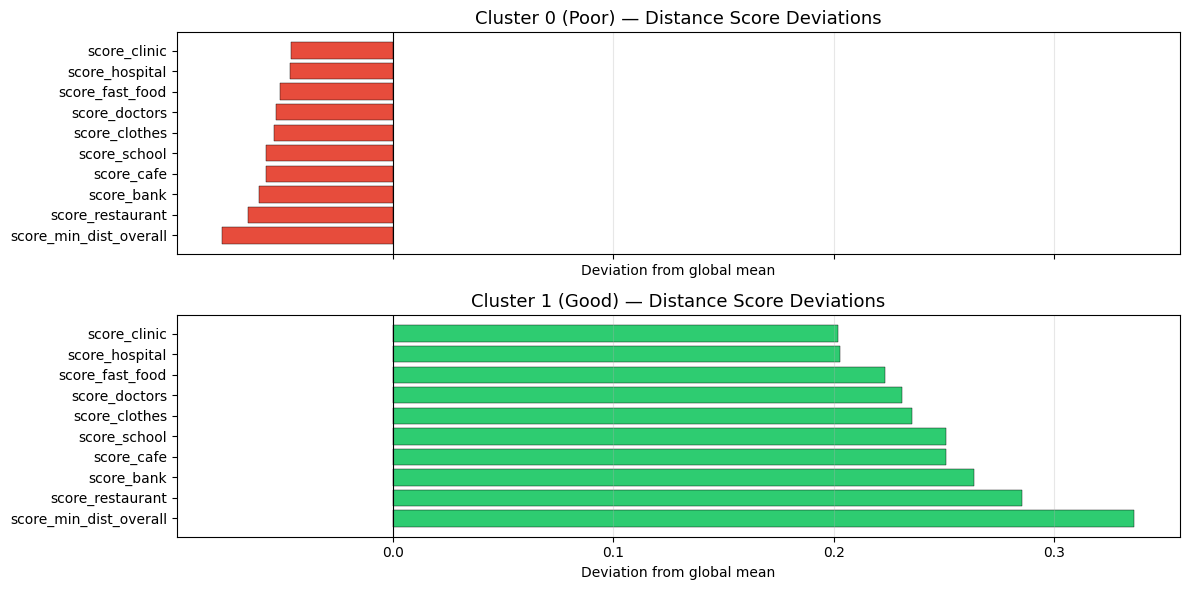

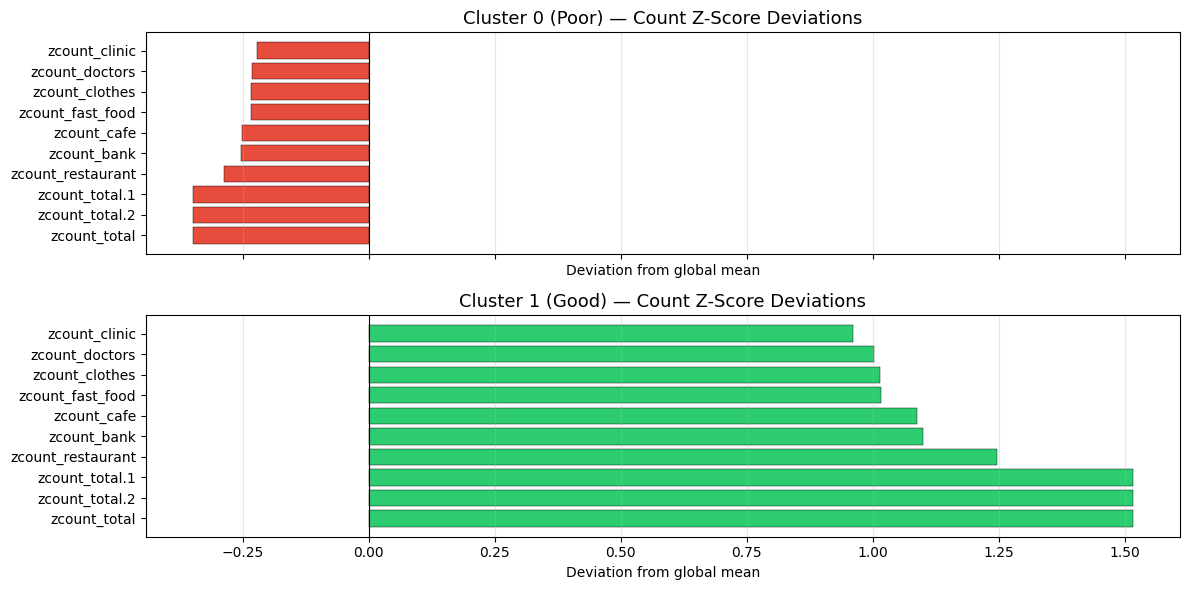

C:\Users\hp\AppData\Local\Temp\ipykernel_12888\1386702525.py:174: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


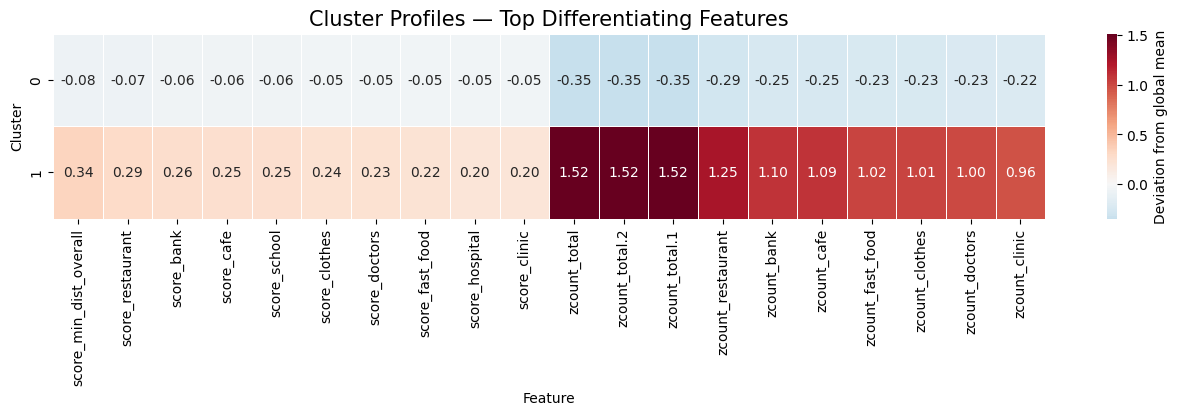

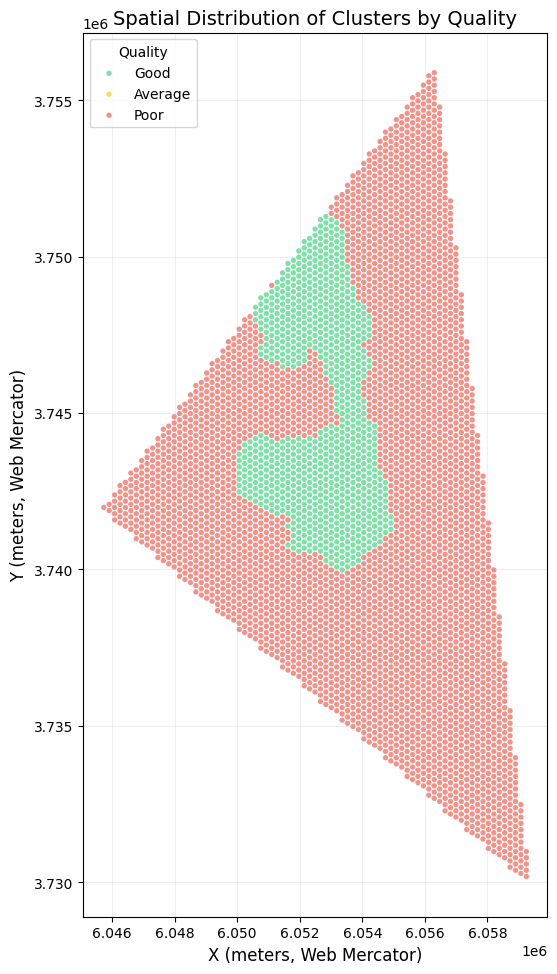


--- Details of 'Good' Cluster(s) ---

Cluster 1:
  Hexagons:           872
  Mean proximity:     0.147
  Mean density:       0.492
  Mean combined:      0.319
  Closest POI types (avg score):
    min_dist_overall: 0.781
    restaurant: 0.456
    park: 0.443
    school: 0.424
    bank: 0.386
  Most abundant POI types (avg z-score):
    total: 1.516
    total.2: 1.516
    total.1: 1.516
    restaurant: 1.247
    bank: 1.101

✅ Saved Cluster_summary.csv
✅ All figures saved.


In [5]:
# ============================================================
# CELL 8: Cluster Profiling & Identify the "Good" Cluster(s)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# ============================================================
# 1. Load clustered data
# ============================================================
df = pd.read_csv('Hexagons_clustered.csv')

# Identify feature columns
score_cols  = [c for c in df.columns if c.startswith('score_')]
zcount_cols = [c for c in df.columns if c.startswith('zcount_')]
feature_cols = score_cols + zcount_cols

# Also the meta columns we normalised
meta_score_col = 'score_min_dist_overall'  # from Cell 6
meta_zcount_col = 'zcount_total'           # from Cell 6
# (These might be named differently; adapt if needed)
if meta_score_col not in df.columns:
    meta_score_col = None
if meta_zcount_col not in df.columns:
    meta_zcount_col = None

# Grab cluster labels
cluster_labels = df['cluster'].values
clusters = sorted(df['cluster'].unique())
K = len(clusters)

print(f"Loaded {len(df)} hexagons, {K} clusters.")
print(f"  Distance score features : {len(score_cols)}")
print(f"  Count z-score features  : {len(zcount_cols)}")

# ============================================================
# 2. Per-cluster mean profiles
# ============================================================
profile = df.groupby('cluster')[feature_cols].mean()
print("\n--- Raw per-cluster mean profile (first 8 features) ---")
print(profile.iloc[:, :8].round(3))

# ============================================================
# 3. Composite indices per hexagon & per cluster
# ============================================================

# 3A. Overall Proximity Score (mean of all score_*)
#     Higher → closer to POIs on average (0..1)
df['proximity_index'] = df[score_cols].mean(axis=1)

# 3B. Overall Density Score (mean of all zcount_*)
#     Higher → more POIs within radius relative to other hexagons
df['density_index'] = df[zcount_cols].mean(axis=1)

# 3C. Combined Score (equally weighted)
df['combined_index'] = (df['proximity_index'] + df['density_index']) / 2

# Per-cluster aggregates
cluster_summary = df.groupby('cluster').agg(
    hexagon_count    = ('id', 'count'),
    mean_proximity   = ('proximity_index', 'mean'),
    mean_density     = ('density_index', 'mean'),
    mean_combined    = ('combined_index', 'mean'),
    median_combined  = ('combined_index', 'median'),
).reset_index()

cluster_summary = cluster_summary.sort_values('mean_combined', ascending=False)
cluster_summary['rank'] = range(1, K+1)

print("\n--- Cluster Summary (ranked by combined index) ---")
print(cluster_summary.to_string(index=False))

# ============================================================
# 4. Identify "Good", "Average", "Poor" clusters
# ============================================================
# Top cluster(s) = Good, bottom = Poor, middle = Average
# You can adjust thresholds.
top_clusters = cluster_summary[cluster_summary['rank'] <= max(1, K//3)]['cluster'].tolist()
bottom_clusters = cluster_summary[cluster_summary['rank'] > K - max(1, K//3)]['cluster'].tolist()
mid_clusters = [c for c in clusters if c not in top_clusters and c not in bottom_clusters]

print(f"\n--- Cluster Classification ---")
print(f"  Good    : {top_clusters}")
print(f"  Average : {mid_clusters}")
print(f"  Poor    : {bottom_clusters}")

# Map labels
quality_map = {}
for c in top_clusters:
    quality_map[c] = 'Good'
for c in mid_clusters:
    quality_map[c] = 'Average'
for c in bottom_clusters:
    quality_map[c] = 'Poor'
df['quality'] = df['cluster'].map(quality_map)

# ============================================================
# 5. Visualize cluster profiles (diverging bar chart)
# ============================================================

# 5A. Distance scores: deviation from global mean
global_mean_score = df[score_cols].mean()
profile_score_deviation = (profile[score_cols] - global_mean_score)  # rows: cluster, cols: feature

# Plot top 10 most variable score features
score_feature_variance = profile_score_deviation.var(axis=0).sort_values(ascending=False)
top_score_feats = score_feature_variance.head(10).index.tolist()

fig, axes = plt.subplots(K, 1, figsize=(12, 3*K), sharex=True)
if K == 1:
    axes = [axes]

for i, clus in enumerate(clusters):
    ax = axes[i]
    deviations = profile_score_deviation.loc[clus, top_score_feats]
    colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in deviations]
    ax.barh(top_score_feats, deviations, color=colors, edgecolor='black', linewidth=0.3)
    ax.axvline(0, color='black', linewidth=0.8)
    quality_label = quality_map.get(clus, '')
    ax.set_title(f'Cluster {clus} ({quality_label}) — Distance Score Deviations', fontsize=13)
    ax.set_xlabel('Deviation from global mean')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_profile_distance_deviations.png', dpi=150, bbox_inches='tight')
plt.show()

# 5B. Count z-scores: deviation from global mean
global_mean_zcount = df[zcount_cols].mean()
profile_zcount_deviation = (profile[zcount_cols] - global_mean_zcount)

zcount_feature_variance = profile_zcount_deviation.var(axis=0).sort_values(ascending=False)
top_zcount_feats = zcount_feature_variance.head(10).index.tolist()

fig, axes = plt.subplots(K, 1, figsize=(12, 3*K), sharex=True)
if K == 1:
    axes = [axes]

for i, clus in enumerate(clusters):
    ax = axes[i]
    deviations = profile_zcount_deviation.loc[clus, top_zcount_feats]
    colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in deviations]
    ax.barh(top_zcount_feats, deviations, color=colors, edgecolor='black', linewidth=0.3)
    ax.axvline(0, color='black', linewidth=0.8)
    quality_label = quality_map.get(clus, '')
    ax.set_title(f'Cluster {clus} ({quality_label}) — Count Z-Score Deviations', fontsize=13)
    ax.set_xlabel('Deviation from global mean')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_profile_count_deviations.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 6. Heatmap of full cluster profile (top differentiating features)
# ============================================================
# Combine top score and top zcount features
top_all_feats = list(top_score_feats) + list(top_zcount_feats)

# Build matrix: cluster x feature, values = deviation from global mean
all_deviation = pd.concat([
    profile_score_deviation[top_score_feats],
    profile_zcount_deviation[top_zcount_feats]
], axis=1)

fig, ax = plt.subplots(figsize=(max(10, len(top_all_feats)*0.8), K*1.2))
sns.heatmap(all_deviation, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Deviation from global mean'})
ax.set_title('Cluster Profiles — Top Differentiating Features', fontsize=15)
ax.set_xlabel('Feature')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig('cluster_profile_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 7. Spatial map colored by quality (Good / Average / Poor)
# ============================================================
quality_colors = {'Good': '#2ecc71', 'Average': '#f1c40f', 'Poor': '#e74c3c'}

fig, ax = plt.subplots(figsize=(12, 10))
for q, qcol in quality_colors.items():
    subset = df[df['quality'] == q]
    ax.scatter(subset['center_x'], subset['center_y'],
               c=qcol, s=15, alpha=0.6, edgecolors='none', label=q)

ax.set_xlabel('X (meters, Web Mercator)', fontsize=12)
ax.set_ylabel('Y (meters, Web Mercator)', fontsize=12)
ax.set_title('Spatial Distribution of Clusters by Quality', fontsize=14)
ax.set_aspect('equal')
ax.legend(title='Quality', loc='best')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('cluster_quality_map.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 8. Summary statistics of the "Good" cluster(s)
# ============================================================
print("\n--- Details of 'Good' Cluster(s) ---")
for c in top_clusters:
    sub = df[df['cluster'] == c]
    print(f"\nCluster {c}:")
    print(f"  Hexagons:           {len(sub)}")
    print(f"  Mean proximity:     {sub['proximity_index'].mean():.3f}")
    print(f"  Mean density:       {sub['density_index'].mean():.3f}")
    print(f"  Mean combined:      {sub['combined_index'].mean():.3f}")
    
    # Top 5 POI types where this cluster excels (distance)
    top_dist_for_this_cluster = (
        sub[score_cols].mean().sort_values(ascending=False).head(5)
    )
    print(f"  Closest POI types (avg score):")
    for feat, val in top_dist_for_this_cluster.items():
        print(f"    {feat.replace('score_','')}: {val:.3f}")
    
    # Top 5 POI types where this cluster excels (count)
    top_cnt_for_this_cluster = (
        sub[zcount_cols].mean().sort_values(ascending=False).head(5)
    )
    print(f"  Most abundant POI types (avg z-score):")
    for feat, val in top_cnt_for_this_cluster.items():
        print(f"    {feat.replace('zcount_','')}: {val:.3f}")

# ============================================================
# 9. Save summary table
# ============================================================
cluster_summary.to_csv('Cluster_summary.csv', index=False)
print("\n✅ Saved Cluster_summary.csv")
print("✅ All figures saved.")
